# Active learning Model on Galaxy Zoo Data

## Installation of dataset

Use the following command in terminal to install the dataset: 
```
kaggle competitions download -c galaxy-zoo-the-galaxy-challenge
```

You will need the following packages:

```
pip install numpy matplotlib scikit-image scikit-learn pandas kaggle
```

### Imports

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io, color, filters
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from scipy.stats import entropy
import os

### Read in file and choose a feature

In this case "Class1.1" is the smoothness of the galaxy.

Anything above 0.5 is considered a "smooth" galaxy

In [55]:
labels = pd.read_csv("training_solutions_rev1.csv")
y = labels["Class1.1"].values
galaxy_ids = labels["GalaxyID"].values
y_bin = (y > 0.5).astype(int)

Define a function to extract the features from the image you want to use as your training set. 

Here, we are taking the average color in grayscale, the mean g - r color from the image channels, and the "sharpness" of the edges in the image after applying a filter. 

Sharper edges generally mean spiral galaxies, wheras smoother edges mean elliptical. Very simple approximation.

In [56]:
def extract_features(img_path):
    img = io.imread(img_path)
    gray = color.rgb2gray(img)
    f1 = gray.mean()
    f2 = img[:, :, 2].mean() - img[:, :, 0].mean()
    edges = filters.sobel(gray)
    f3 = edges.mean()
    return np.array([f1, f2, f3])

Choose a subset of galaxies (for ease of computing) and append to an array to train features.

In [57]:
N = 3000
X = []

for gid in galaxy_ids[:N]:
    path = f"images_training_rev1/{gid}.jpg"
    X.append(extract_features(path))

X = np.array(X)
y_bin_small = y_bin[:N]

Create a test/train split, and from the train set choose an initial fraction as the labelled set.

In [58]:
X_train, X_pool, y_train, y_pool = train_test_split(
    X, y_bin_small, test_size=0.95, random_state=457
)
initial_size = int(0.05 * len(X_train))
X_labeled = X_train[:initial_size]
y_labeled = y_train[:initial_size]

Train a classifier. In this case, I chose a Random Forest Classifier. 

In [59]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_labeled, y_labeled)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
probs = model.predict_proba(X_pool)
uncertainty = entropy(probs.T) 

Pick the 20 most uncertain galaxies and simulate the human labelling by revealing the labels of those galaxies.

In [61]:
query_idx = np.argsort(uncertainty)[-20:]
X_query = X_pool[query_idx]
y_query = y_pool[query_idx]

X_labeled = np.vstack([X_labeled, X_query])
y_labeled = np.append(y_labeled, y_query)

mask = np.ones(len(X_pool), dtype=bool)
mask[query_idx] = False
X_pool = X_pool[mask]
y_pool = y_pool[mask]

Refit the model and find the accuracy of the model.

In [62]:
model.fit(X_labeled, y_labeled)
y_pred = model.predict(X_train)
acc = accuracy_score(y_train, y_pred)
print("Accuracy after one active learning step:", acc)

Accuracy after one active learning step: 0.49333333333333335


Repeat the active learning steps for n iterations.

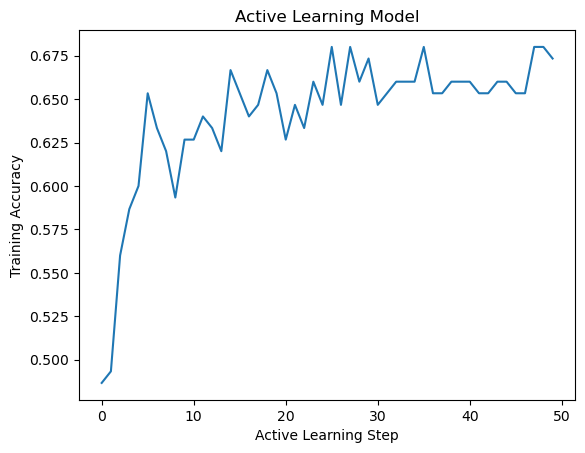

In [63]:
accuracies = []

for step in range(50):
    model.fit(X_labeled, y_labeled)
    
    y_pred = model.predict(X_train)
    acc = accuracy_score(y_train, y_pred)
    accuracies.append(acc)

    probs = model.predict_proba(X_pool)
    uncertainty = entropy(probs.T)

    query_idx = np.argsort(uncertainty)[-20:]
    X_query = X_pool[query_idx]
    y_query = y_pool[query_idx]

    X_labeled = np.vstack([X_labeled, X_query])
    y_labeled = np.append(y_labeled, y_query)

    mask = np.ones(len(X_pool), dtype=bool)
    mask[query_idx] = False
    X_pool = X_pool[mask]
    y_pool = y_pool[mask]

plt.plot(accuracies)
plt.xlabel("Active Learning Step")
plt.ylabel("Training Accuracy")
plt.title("Active Learning Model")
plt.show()

As we can see in the graph, the accuray of the active learning model improves with the number of steps. 

This is a very simplified model, however, and more information is needed to improve the classifications. 

There are many many more features in the dataset, but adding more to the model would require more compute power and time.